# Clinical Feature Selection Benchmark
## Breast Cancer Wisconsin Diagnostic Dataset

This notebook demonstrates a single-dataset workflow for comparing feature selection methods under a clinically guided relevance layer.

### Goals
- Compare LASSO, ANOVA, mRMR, and Random Forest feature importance
- Train Logistic Regression, Random Forest, and XGBoost
- Measure predictive performance
- Measure feature stability
- Apply a simple clinical relevance filter

### Note
This notebook is a sample implementation for one dataset only. It is designed to validate the workflow before scaling to multiple diseases.

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Scikit-learn utilities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

# 2. Dataset Loading and Initial Exploration

This section loads the **Breast Cancer Wisconsin Diagnostic Dataset** from scikit-learn and performs an initial exploration.

Understanding the dataset helps us:

- identify the number of observations and features
- understand the prediction target
- inspect feature names
- verify data quality
- check whether missing values exist
- examine class distribution

A clear understanding of the dataset is essential before preprocessing and model development.

In [8]:
# Load dataset
cancer = load_breast_cancer()

# Create feature dataframe
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Create target series
y = pd.Series(
    cancer.target,
    name="target"
)


In [9]:

# Combine for easier exploration
df = pd.concat([X, y], axis=1)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Dataset Dimensions

The first step is to determine the size of the dataset.

We inspect:

- Number of samples (patients)
- Number of predictor variables (features)
- Number of target classes

In [12]:
print(f"Number of Samples : {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"Target Classes    : {len(cancer.target_names)}")

Number of Samples : 569
Number of Features: 30
Target Classes    : 2


## Feature Names

Machine learning models use numerical values, but researchers must understand what those variables represent.

Listing all feature names allows us to identify the clinical measurements available in the dataset.

In [13]:
feature_df = pd.DataFrame({
    "Feature Number": range(1, len(cancer.feature_names)+1),
    "Feature Name": cancer.feature_names
})

feature_df

,Feature Number,Feature Name
0,1,mean radius
1,2,mean texture
2,3,mean perimeter
3,4,mean area
4,5,mean smoothness
5,6,mean compactness
6,7,mean concavity
7,8,mean concave points
8,9,mean symmetry
9,10,mean fractal dimension


## Target Classes

The prediction target indicates whether a tumour is:

- Malignant
- Benign

Understanding the target labels is important because this is a binary classification problem.

In [14]:
print("Target Labels")

for i, label in enumerate(cancer.target_names):
    print(f"{i} : {label}")

Target Labels
0 : malignant
1 : benign


## Display the First Five Records

Viewing the first few observations helps verify that the dataset has been loaded correctly and provides an overview of the feature values.

In [15]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Dataset Information

The `info()` function provides:

- number of observations
- feature data types
- non-null values

This helps identify potential missing values and confirms whether the variables are stored in the expected format.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## Statistical Summary

Descriptive statistics provide an overview of the numerical distribution of each feature.

These statistics include:

- mean
- standard deviation
- minimum
- maximum
- quartiles

They help identify scale differences and potential outliers before preprocessing.

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Missing Value Analysis

Clinical datasets frequently contain missing values.

Before proceeding to preprocessing, we verify whether any values are missing.

In [18]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Feature": missing.index,
    "Missing Values": missing.values
})

missing_df.head()

,Feature,Missing Values
0,mean radius,0
1,mean texture,0
2,mean perimeter,0
3,mean area,0
4,mean smoothness,0


In [19]:
print("Total Missing Values")

print(df.isnull().sum().sum())

Total Missing Values
0


## Class Distribution

Finally, we inspect the number of observations belonging to each class.

A balanced dataset generally leads to more reliable model evaluation, whereas severe class imbalance may require additional preprocessing techniques.

In [20]:
class_distribution = y.value_counts().rename_axis("Class").reset_index(name="Count")

class_distribution["Class"] = class_distribution["Class"].map({
    0: "Malignant",
    1: "Benign"
})

class_distribution

,Class,Count
0,Benign,357
1,Malignant,212


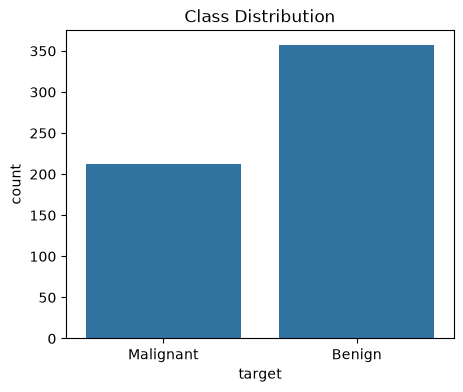

In [21]:
plt.figure(figsize=(5,4))

sns.countplot(
    x=y,
)

plt.xticks(
    [0,1],
    ["Malignant","Benign"]
)

plt.title("Class Distribution")

plt.show()

# 3. Data Preprocessing

## Train-Test Split

The dataset is divided into:

- **Training Set (80%)**: Used for feature selection and model training.
- **Testing Set (20%)**: Used only for final model evaluation.

A stratified split is used to preserve the proportion of malignant and benign cases in both subsets.

In [22]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed Successfully!\n")

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"Training Features: {X_train.shape[1]}")
print(f"Testing Features : {X_test.shape[1]}")

Train-Test Split Completed Successfully!

Training Samples : 455
Testing Samples  : 114
Training Features: 30
Testing Features : 30


### Why Stratified Splitting?

The Breast Cancer dataset contains two classes:

- Malignant
- Benign

A stratified split ensures that both classes are represented in approximately the same proportion in the training and testing datasets.

This produces a more reliable evaluation of model performance.

In [23]:
# Verify Class Distribution in Train and Test Sets

train_distribution = (
    y_train.value_counts(normalize=True)
    .rename_axis("Class")
    .reset_index(name="Proportion")
)

train_distribution["Class"] = train_distribution["Class"].map({
    0: "Malignant",
    1: "Benign"
})

test_distribution = (
    y_test.value_counts(normalize=True)
    .rename_axis("Class")
    .reset_index(name="Proportion")
)

test_distribution["Class"] = test_distribution["Class"].map({
    0: "Malignant",
    1: "Benign"
})

print("Training Class Distribution")
display(train_distribution)

print("\nTesting Class Distribution")
display(test_distribution)

Training Class Distribution


,Class,Proportion
0,Benign,0.626374
1,Malignant,0.373626



Testing Class Distribution


,Class,Proportion
0,Benign,0.631579
1,Malignant,0.368421


## Feature Scaling

The Breast Cancer dataset contains measurements with different numerical ranges.

For example:

- Mean Radius
- Mean Area
- Worst Perimeter

These variables have different scales.

Many machine learning algorithms, including Logistic Regression, LASSO, and Support Vector Machines, perform better when features are standardized.

Standardization transforms each feature so that:

- Mean = 0
- Standard Deviation = 1

To avoid data leakage, the scaler is fitted **only on the training data**, and the same transformation is applied to the testing data.

In [24]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

print(f"Training Shape : {X_train_scaled.shape}")
print(f"Testing Shape  : {X_test_scaled.shape}")

Feature Scaling Completed Successfully!
Training Shape : (455, 30)
Testing Shape  : (114, 30)


### Preventing Data Leakage

The scaler learns the mean and standard deviation of the training dataset.

If the scaler were fitted on the entire dataset before splitting, information from the testing data would leak into the training process.

Therefore:

- `fit_transform()` is applied only to the training data.
- `transform()` is applied to the testing data using the statistics learned from the training set.

This ensures a fair and unbiased evaluation.

In [25]:
# Convert scaled arrays back to DataFrames for easier exploration

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

print("Scaled DataFrames Created Successfully!")

Scaled DataFrames Created Successfully!


## Interpretation

The dataset has now been successfully preprocessed.

The key preprocessing steps include:

- Stratified train-test splitting
- Feature standardization
- Prevention of data leakage
- Preservation of feature names after scaling

The processed training dataset is now ready for feature selection methods, while the testing dataset will remain untouched until model evaluation.

# 4. Feature Selection

Feature selection aims to identify the most informative variables while removing redundant or less useful features.

Benefits of feature selection include:

- Reduced model complexity
- Improved interpretability
- Faster training
- Reduced overfitting
- Better generalization

In this notebook, four feature selection methods are compared:

1. ANOVA F-test
2. LASSO
3. mRMR
4. Random Forest Feature Importance

Each method selects the **top 10 features**, which are then used for model training and evaluation.

## 4.1 ANOVA Feature Selection

### Why ANOVA?

The Analysis of Variance (ANOVA) F-test is a **filter-based feature selection method**.

It evaluates each feature independently by measuring how well it separates the target classes.

Features with higher F-scores have greater discriminatory power and are considered more informative for classification.

Since ANOVA evaluates each feature individually, it is computationally efficient and serves as a useful baseline for comparison.

In [26]:
# Number of features to select
k = 10

# Initialize ANOVA selector
anova_selector = SelectKBest(
    score_func=f_classif,
    k=k
)

# Fit only on training data
anova_selector.fit(X_train_scaled, y_train)

# Transform training and testing sets
X_train_anova = anova_selector.transform(X_train_scaled)
X_test_anova = anova_selector.transform(X_test_scaled)

In [27]:
selected_mask = anova_selector.get_support()

anova_features = X_train_scaled.columns[selected_mask]

anova_scores = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "F Score": anova_selector.scores_
})

anova_scores = anova_scores.sort_values(
    by="F Score",
    ascending=False
)

anova_scores.head(10)

,Feature,F Score
27,worst concave points,795.223341
22,worst perimeter,719.598823
7,mean concave points,703.364031
20,worst radius,687.430367
2,mean perimeter,565.485755
23,worst area,541.713694
0,mean radius,523.613907
3,mean area,469.516453
6,mean concavity,416.374874
26,worst concavity,365.747389


### Top Features Selected by ANOVA

The following table lists the ten highest-ranked features according to the ANOVA F-test.

Higher F-scores indicate stronger statistical association with the target variable.

In [28]:
print("Selected Features\n")

for feature in anova_features:
    print(f"• {feature}")

Selected Features

• mean radius
• mean perimeter
• mean area
• mean concavity
• mean concave points
• worst radius
• worst perimeter
• worst area
• worst concavity
• worst concave points


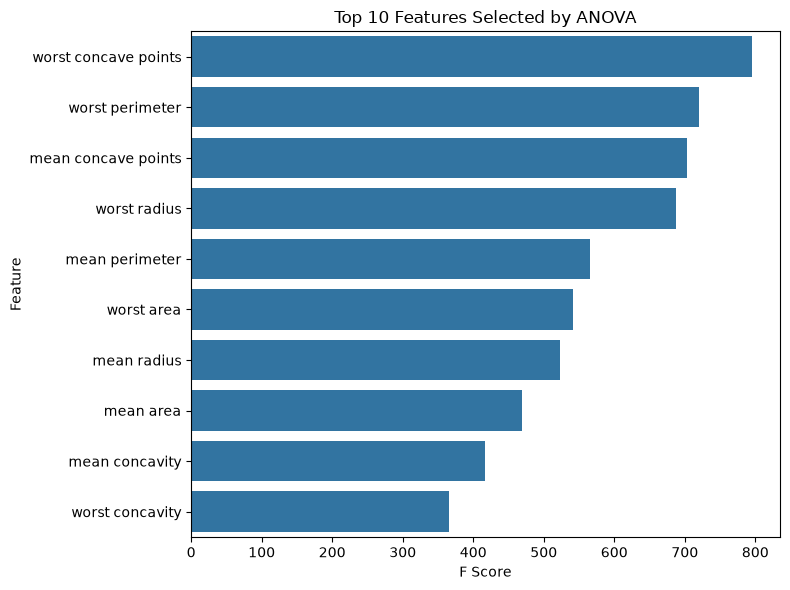

In [29]:
plt.figure(figsize=(8,6))

top10 = anova_scores.head(10)

sns.barplot(
    data=top10,
    y="Feature",
    x="F Score"
)

plt.title("Top 10 Features Selected by ANOVA")

plt.tight_layout()

plt.show()

### Interpretation

The ANOVA F-test ranked the features according to their individual statistical association with the target variable.

The selected features represent the strongest independent predictors of breast cancer diagnosis according to this filter-based approach.

These features will be used as inputs for the predictive models in later sections, allowing comparison with other feature selection methods.

## 4.2 Minimum Redundancy Maximum Relevance (mRMR)

### Why mRMR?

Unlike ANOVA, which evaluates each feature independently, **Minimum Redundancy Maximum Relevance (mRMR)** considers both the relationship between each feature and the target variable, as well as the redundancy among the selected features.

The objective is to identify features that:

- have high predictive relevance
- contribute unique information
- reduce redundancy within the final feature subset

This makes mRMR particularly suitable for biomedical datasets, where multiple clinical variables are often highly correlated.

In [30]:
# import

from mrmr import mrmr_classif

In [31]:
# Number of features
k = 10

# Perform mRMR feature selection
mrmr_features = mrmr_classif(
    X=X_train_scaled,
    y=y_train,
    K=k
)

print("Selected Features using mRMR:\n")

for feature in mrmr_features:
    print(f"• {feature}")

100%|██████████| 10/10 [00:00<00:00, 22.21it/s]

Selected Features using mRMR:

• worst concave points
• worst perimeter
• mean concave points
• worst radius
• mean perimeter
• worst area
• mean radius
• worst concavity
• mean concavity
• mean area


In [32]:
mrmr_df = pd.DataFrame({
    "Rank": range(1, len(mrmr_features)+1),
    "Feature": mrmr_features
})

mrmr_df

,Rank,Feature
0,1,worst concave points
1,2,worst perimeter
2,3,mean concave points
3,4,worst radius
4,5,mean perimeter
5,6,worst area
6,7,mean radius
7,8,worst concavity
8,9,mean concavity
9,10,mean area


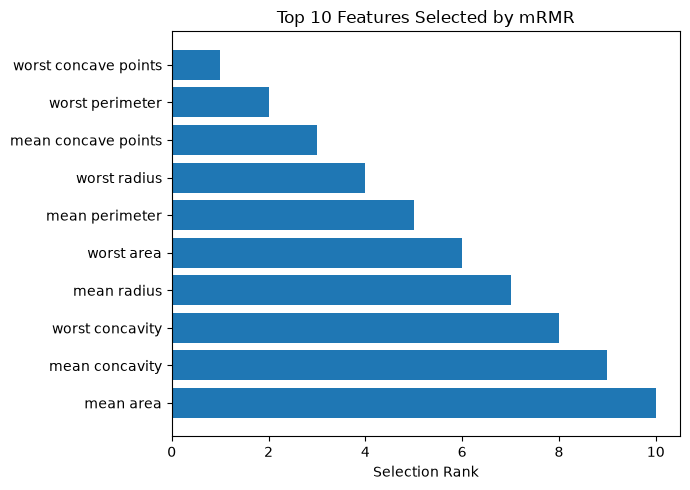

In [33]:
plt.figure(figsize=(7,5))

plt.barh(
    mrmr_df["Feature"],
    mrmr_df["Rank"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features Selected by mRMR")

plt.xlabel("Selection Rank")

plt.tight_layout()

plt.show()

In [34]:
# comparision of ANOVA and mRMR selected features

comparison_df = pd.DataFrame({
    "ANOVA": list(anova_features),
    "mRMR": mrmr_features
})

comparison_df

,ANOVA,mRMR
0,mean radius,worst concave points
1,mean perimeter,worst perimeter
2,mean area,mean concave points
3,mean concavity,worst radius
4,mean concave points,mean perimeter
5,worst radius,worst area
6,worst perimeter,mean radius
7,worst area,worst concavity
8,worst concavity,mean concavity
9,worst concave points,mean area


### Interpretation

The mRMR algorithm selected ten features that maximize predictive relevance while minimizing redundancy among the selected variables.

Compared with ANOVA, the selected feature subset may contain fewer highly correlated variables, resulting in a more diverse and informative representation of the dataset.

These selected features will be used during model training and compared with the feature subsets produced by the other feature selection methods.

## 4.3 Random Forest Feature Importance

Random Forest is an ensemble learning algorithm that builds multiple decision trees.

During training, the model estimates how much each feature contributes to improving classification decisions.

Features with higher importance scores contribute more to reducing prediction error and are considered more informative.

Unlike filter-based methods, Random Forest performs feature selection as part of the model training process, making it an **embedded feature selection method**.

In [35]:
# Number of selected features
k = 10

# Initialize Random Forest
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train only on the training data
rf_selector.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [36]:
# Extract feature importances

feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf_selector.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


In [37]:
# Select top 10 features

rf_features = feature_importance.head(k)["Feature"].tolist()

print("Top 10 Features Selected by Random Forest:\n")

for feature in rf_features:
    print(f"• {feature}")

Top 10 Features Selected by Random Forest:

• worst area
• worst concave points
• worst radius
• mean concave points
• worst perimeter
• mean perimeter
• mean radius
• mean concavity
• mean area
• worst concavity


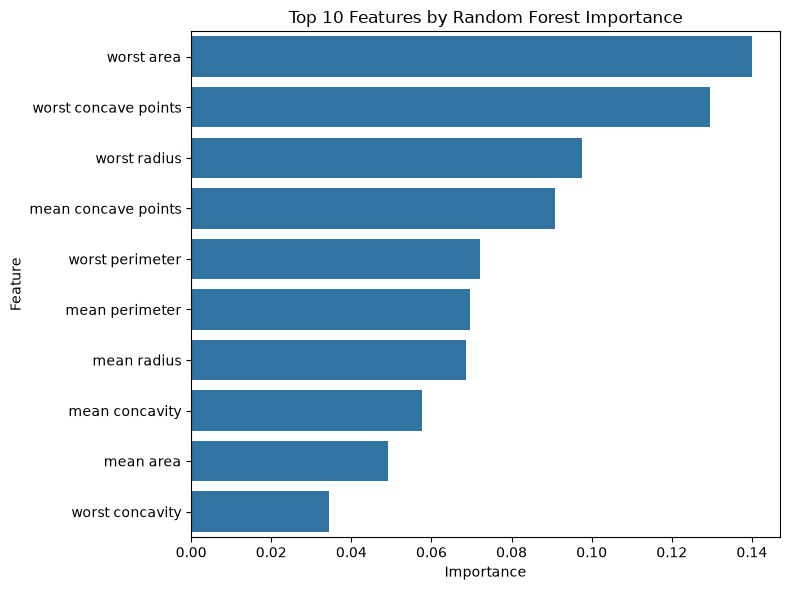

In [38]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    y="Feature",
    x="Importance"
)

plt.title("Top 10 Features by Random Forest Importance")

plt.tight_layout()

plt.show()

### Interpretation

Random Forest ranked the predictor variables according to their contribution to reducing classification error during tree construction.

Unlike ANOVA and mRMR, which evaluate statistical relationships between features and the target variable, Random Forest captures non-linear interactions and complex decision boundaries.

The selected feature subset represents the variables that contributed most to the predictive performance of the ensemble model.

In [42]:
# store selected feature sets

X_train_rf = X_train_scaled[rf_features]

X_test_rf = X_test_scaled[rf_features]

In [43]:
# comparision of ANOVA, mRMR and Random Forest selected features

comparison_df = pd.DataFrame({
    "ANOVA": list(anova_features),
    "mRMR": mrmr_features,
    "Random Forest": rf_features
})

comparison_df

,ANOVA,mRMR,Random Forest
0,mean radius,worst concave points,worst area
1,mean perimeter,worst perimeter,worst concave points
2,mean area,mean concave points,worst radius
3,mean concavity,worst radius,mean concave points
4,mean concave points,mean perimeter,worst perimeter
5,worst radius,worst area,mean perimeter
6,worst perimeter,mean radius,mean radius
7,worst area,worst concavity,mean concavity
8,worst concavity,mean concavity,mean area
9,worst concave points,mean area,worst concavity
